# Phase 03: Exploratory Data Analysis (EDA)

**Objective**

The objective of this notebook is to explore the cleaned dataset to understand:

Feature distributions<br>
Relationships between variables<br>
Trends and patterns<br>
Potential outliers<br>
Correlations<br>
Insights that will guide feature engineering and clustering

**Expected Deliverables**

By the end of this notebook, we should know:

Distribution of every feature<br>
Which variables are skewed<br>
Which variables have low or high variability<br>
Which variables are strongly related<br>
Whether outliers are meaningful<br>
Which features may be engineered<br>
Which features may need transformation<br>
Which variables may dominate clustering

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

eda_df = pd.read_csv("dataset\\clean_dataset.csv")

In [23]:
#Setting display option
pd.set_option("display.max_columns", None)

# Set plotting style
plt.style.use("default")
sns.set_theme(style="whitegrid")

In [27]:
print("Dataset Shape : \n")

print(f"Rows    : {eda_df.shape[0]}")
print(f"Columns : {eda_df.shape[1]}")

Dataset Shape : 

Rows    : 15489
Columns : 23


<h4>Section A: Numerical Variables</h4>

In [30]:
numerical_features = eda_df.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

print(numerical_features)

['FRUITS_VEGGIES', 'DAILY_STRESS', 'PLACES_VISITED', 'CORE_CIRCLE', 'SUPPORTING_OTHERS', 'SOCIAL_NETWORK', 'ACHIEVEMENT', 'DONATION', 'BMI_RANGE', 'TODO_COMPLETED', 'FLOW', 'DAILY_STEPS', 'LIVE_VISION', 'SLEEP_HOURS', 'LOST_VACATION', 'DAILY_SHOUTING', 'SUFFICIENT_INCOME', 'PERSONAL_AWARDS', 'TIME_FOR_PASSION', 'WEEKLY_MEDITATION', 'AGE', 'WORK_LIFE_BALANCE_SCORE']


**Univariate Analysis**

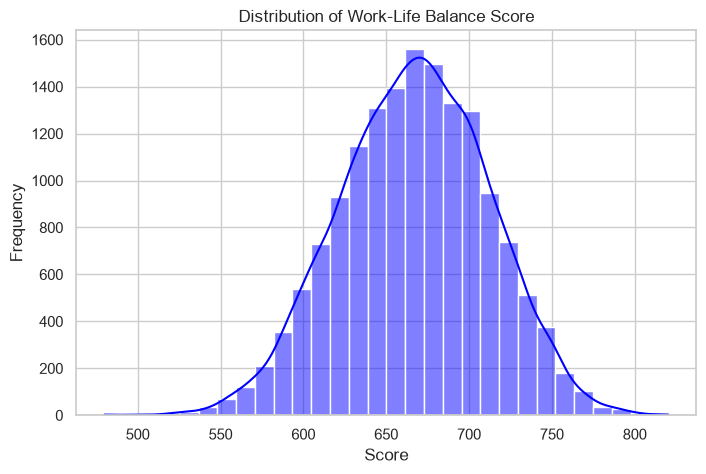

In [32]:
# 1. Univariate: Distribution of the Target Variable
plt.figure(figsize=(8, 5))
sns.histplot(eda_df['WORK_LIFE_BALANCE_SCORE'], bins=30, kde=True, color='blue')
plt.title('Distribution of Work-Life Balance Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

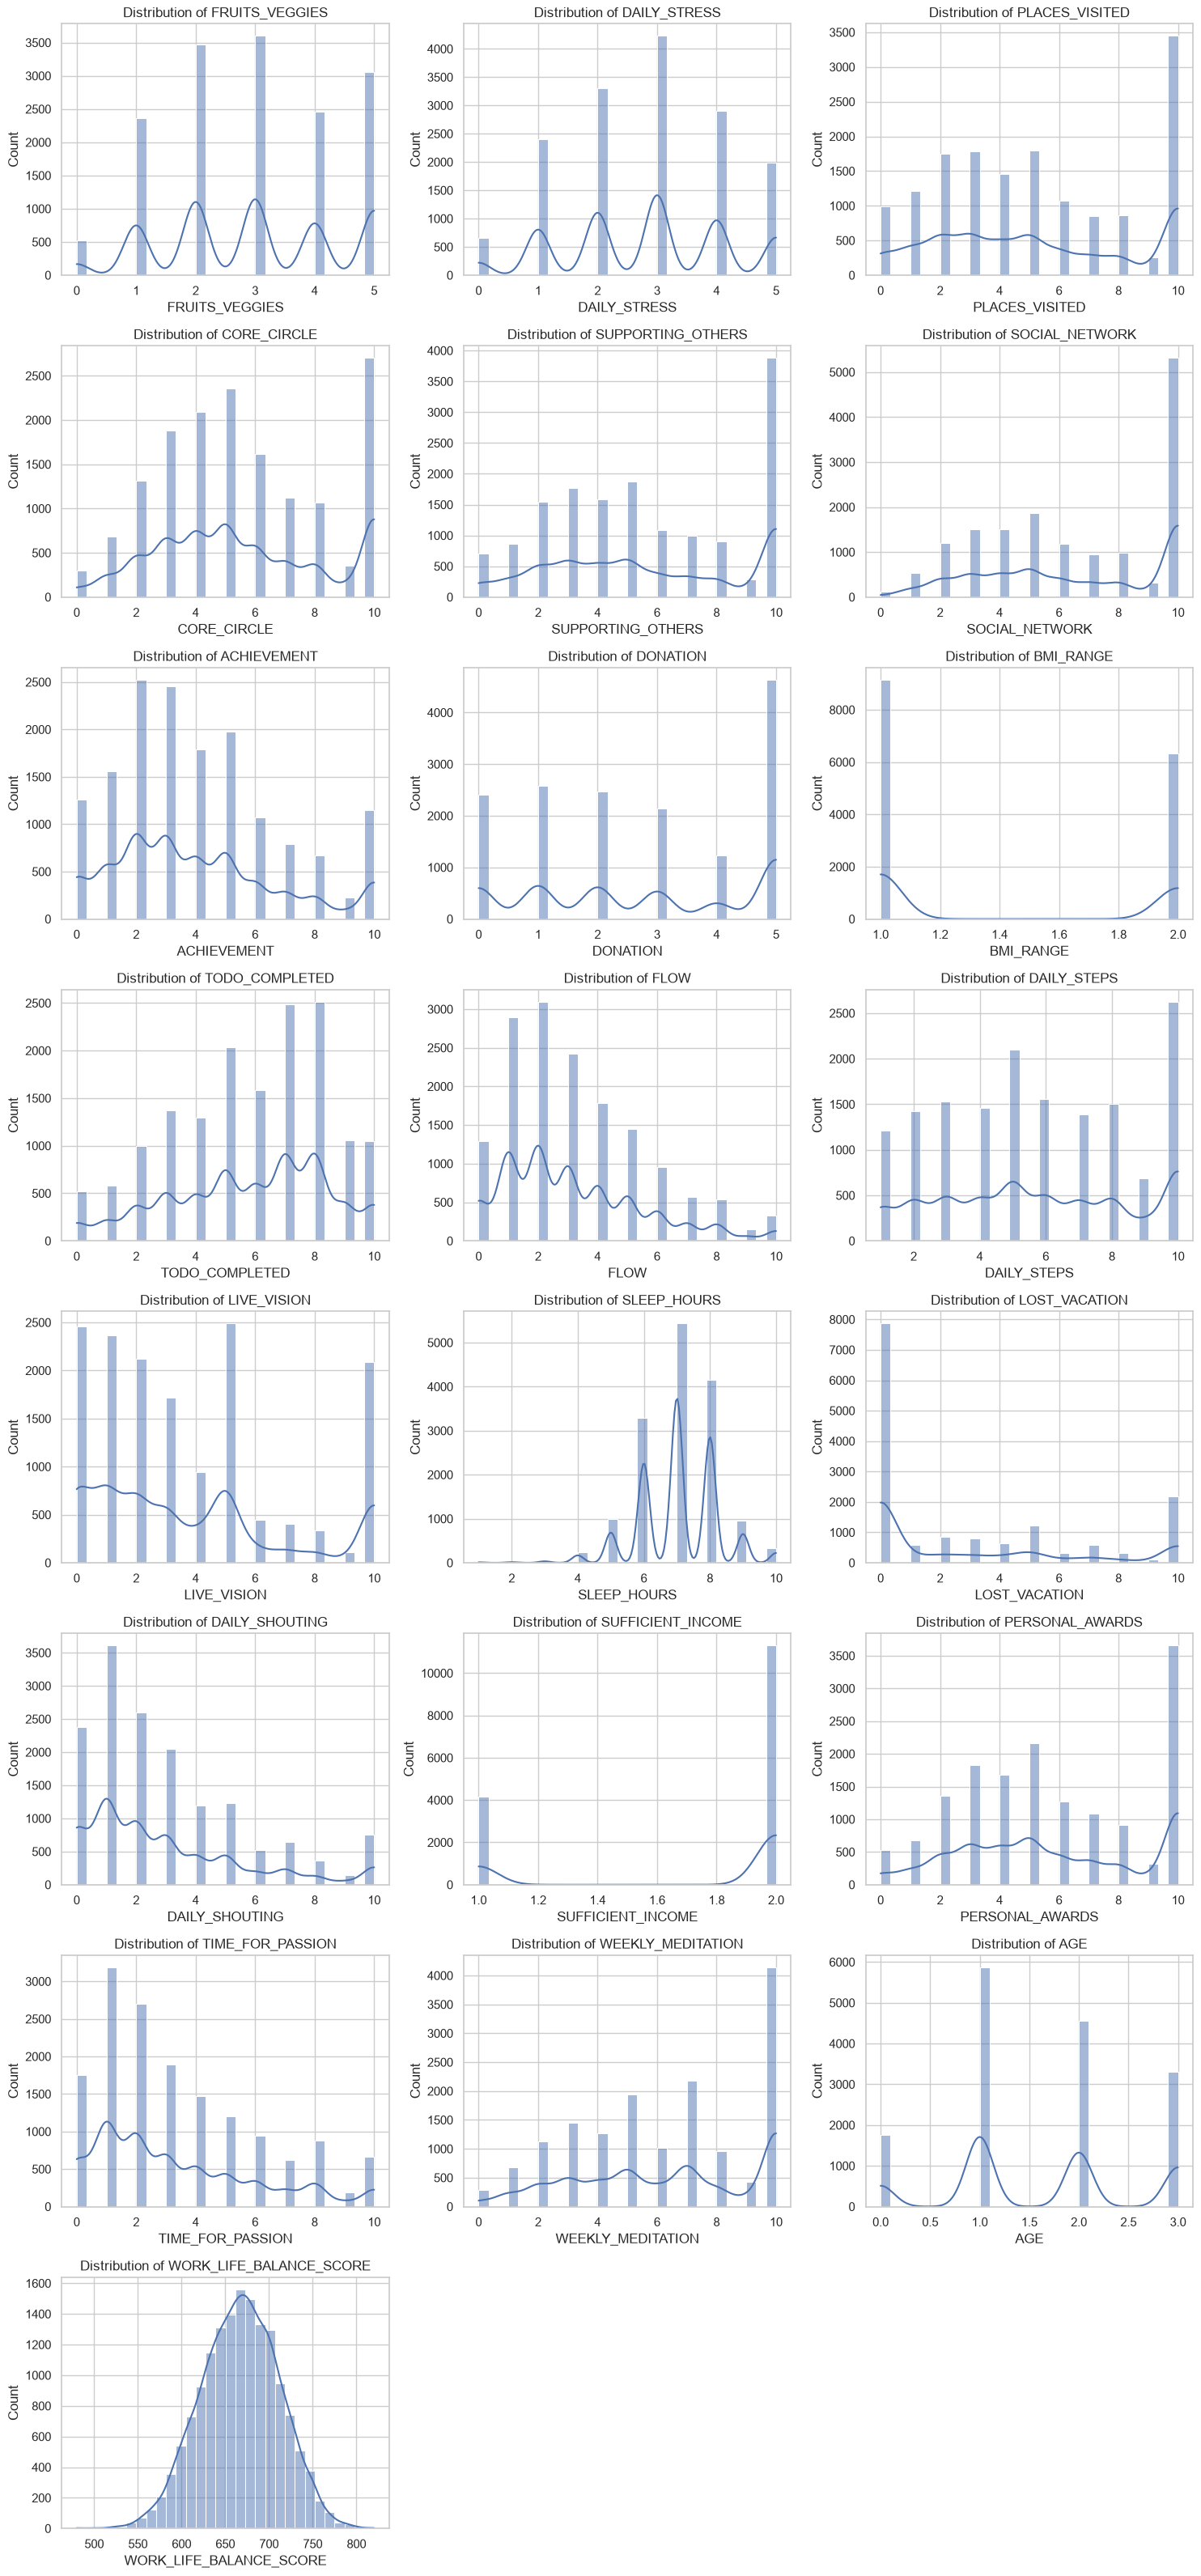

In [34]:
fig, axes = plt.subplots(8, 3, figsize=(15, 32))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(
        data=eda_df,
        x=feature,
        bins=30,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {feature}")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [35]:
distribution_summary = pd.DataFrame({
    "Mean": eda_df[numerical_features].mean(),
    "Median": eda_df[numerical_features].median(),
    "Std Dev": eda_df[numerical_features].std(),
    "Skewness": eda_df[numerical_features].skew(),
    "Kurtosis": eda_df[numerical_features].kurt()
})

display(distribution_summary.round(3))

,Mean,Median,Std Dev,Skewness,Kurtosis
FRUITS_VEGGIES,2.922,3.0,1.443,-0.046,-1.014
DAILY_STRESS,2.792,3.0,1.369,-0.083,-0.805
PLACES_VISITED,5.226,5.0,3.316,0.174,-1.256
CORE_CIRCLE,5.513,5.0,2.839,0.202,-0.968
SUPPORTING_OTHERS,5.619,5.0,3.244,0.055,-1.274
SOCIAL_NETWORK,6.489,6.0,3.085,-0.184,-1.365
ACHIEVEMENT,4.000,3.0,2.760,0.634,-0.353
DONATION,2.716,3.0,1.851,-0.046,-1.439
BMI_RANGE,1.409,1.0,0.492,0.370,-1.863
TODO_COMPLETED,5.750,6.0,2.623,-0.356,-0.707


# Bivariate Analysis

In [41]:
feature_pairs = [

    ("DAILY_STRESS", "SLEEP_HOURS"),

    ("DAILY_STRESS", "WORK_LIFE_BALANCE_SCORE"),

    ("DAILY_STEPS", "WORK_LIFE_BALANCE_SCORE"),

    ("TIME_FOR_PASSION", "WORK_LIFE_BALANCE_SCORE"),

    ("FLOW", "ACHIEVEMENT"),

    ("CORE_CIRCLE", "SOCIAL_NETWORK"),

    ("SUPPORTING_OTHERS", "PERSONAL_AWARDS"),

    ("WEEKLY_MEDITATION", "DAILY_STRESS"),

    ("LIVE_VISION", "ACHIEVEMENT"),

    ("AGE", "WORK_LIFE_BALANCE_SCORE"),

    ("BMI_RANGE", "DAILY_STEPS"),

    ("AGE", "DAILY_STRESS")

]

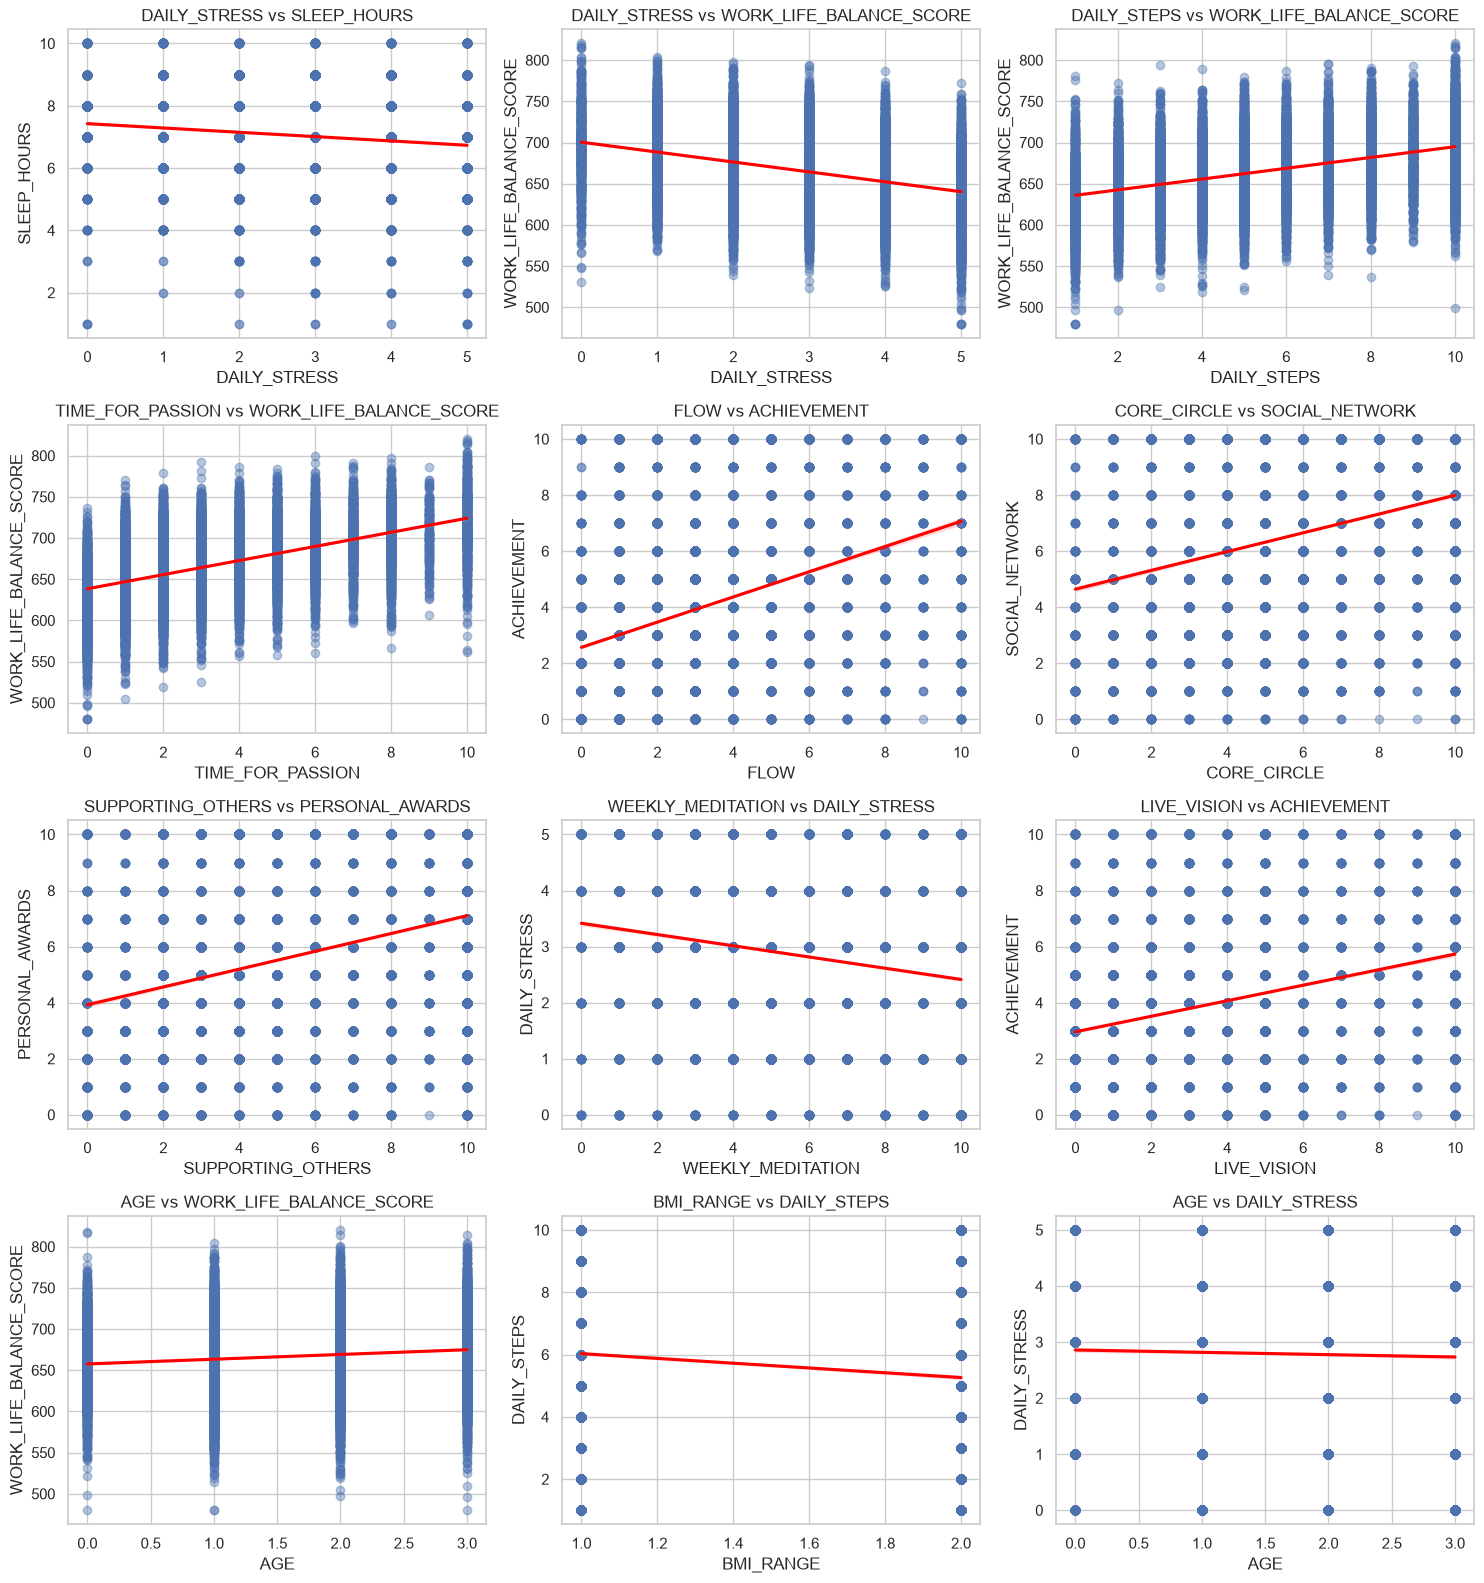

In [42]:
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, (x_feature, y_feature) in enumerate(feature_pairs):

    sns.regplot(
        data=eda_df,
        x=x_feature,
        y=y_feature,
        scatter_kws={"alpha":0.4},
        line_kws={"color":"red"},
        ax=axes[i]
    )
    axes[i].set_title(f"{x_feature} vs {y_feature}")

# Hide any unused subplots if feature_pairs < 12
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Multivariate Analysis

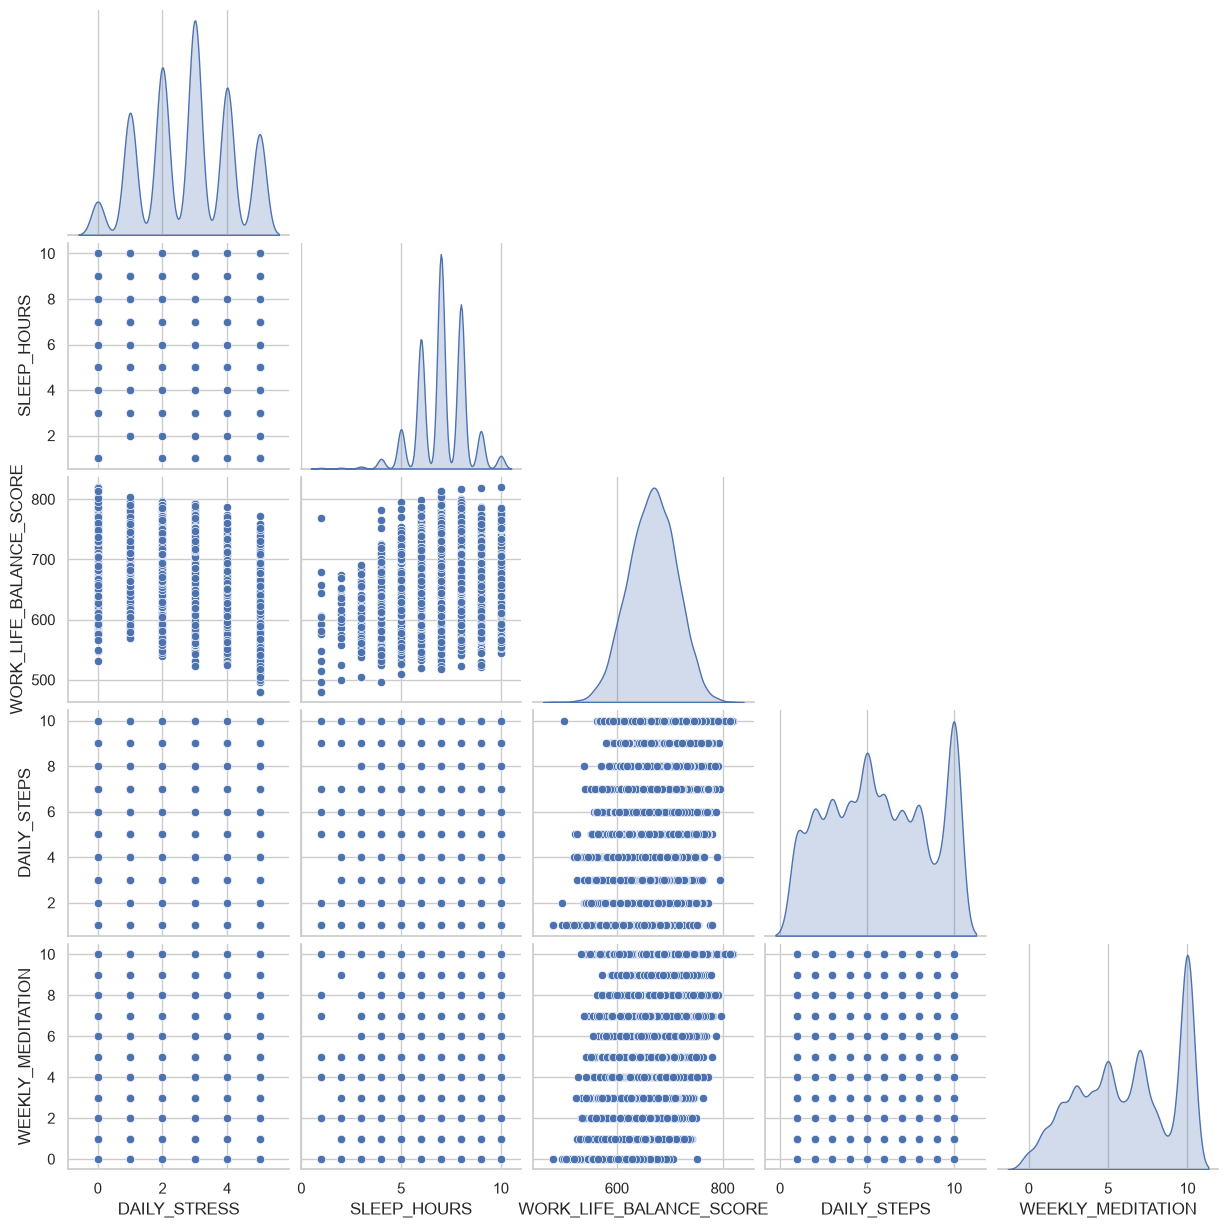

In [43]:
selected_features = [
    "DAILY_STRESS",
    "SLEEP_HOURS",
    "WORK_LIFE_BALANCE_SCORE",
    "DAILY_STEPS",
    "WEEKLY_MEDITATION"
]

sns.pairplot(
    eda_df[selected_features],
    diag_kind="kde",
    corner=True
)

plt.show()

# Parallel cordinates

In [ ]:
from pandas.plotting import parallel_coordinates

parallel_features = [
    "GENDER_Male",
    "DAILY_STRESS",
    "SLEEP_HOURS",
    "DAILY_STEPS"
]

parallel_df = eda_df[parallel_features].copy()

parallel_df["GENDER_Male"] = parallel_df["GENDER_Male"].astype(str)

plt.figure(figsize=(12,6))

parallel_coordinates(
    parallel_df,
    class_column="GENDER_Male",
    alpha=0.2
)

plt.title("Parallel Coordinate Plot")

plt.xticks(rotation=30)

plt.show()


This plot is useless until we scale the data


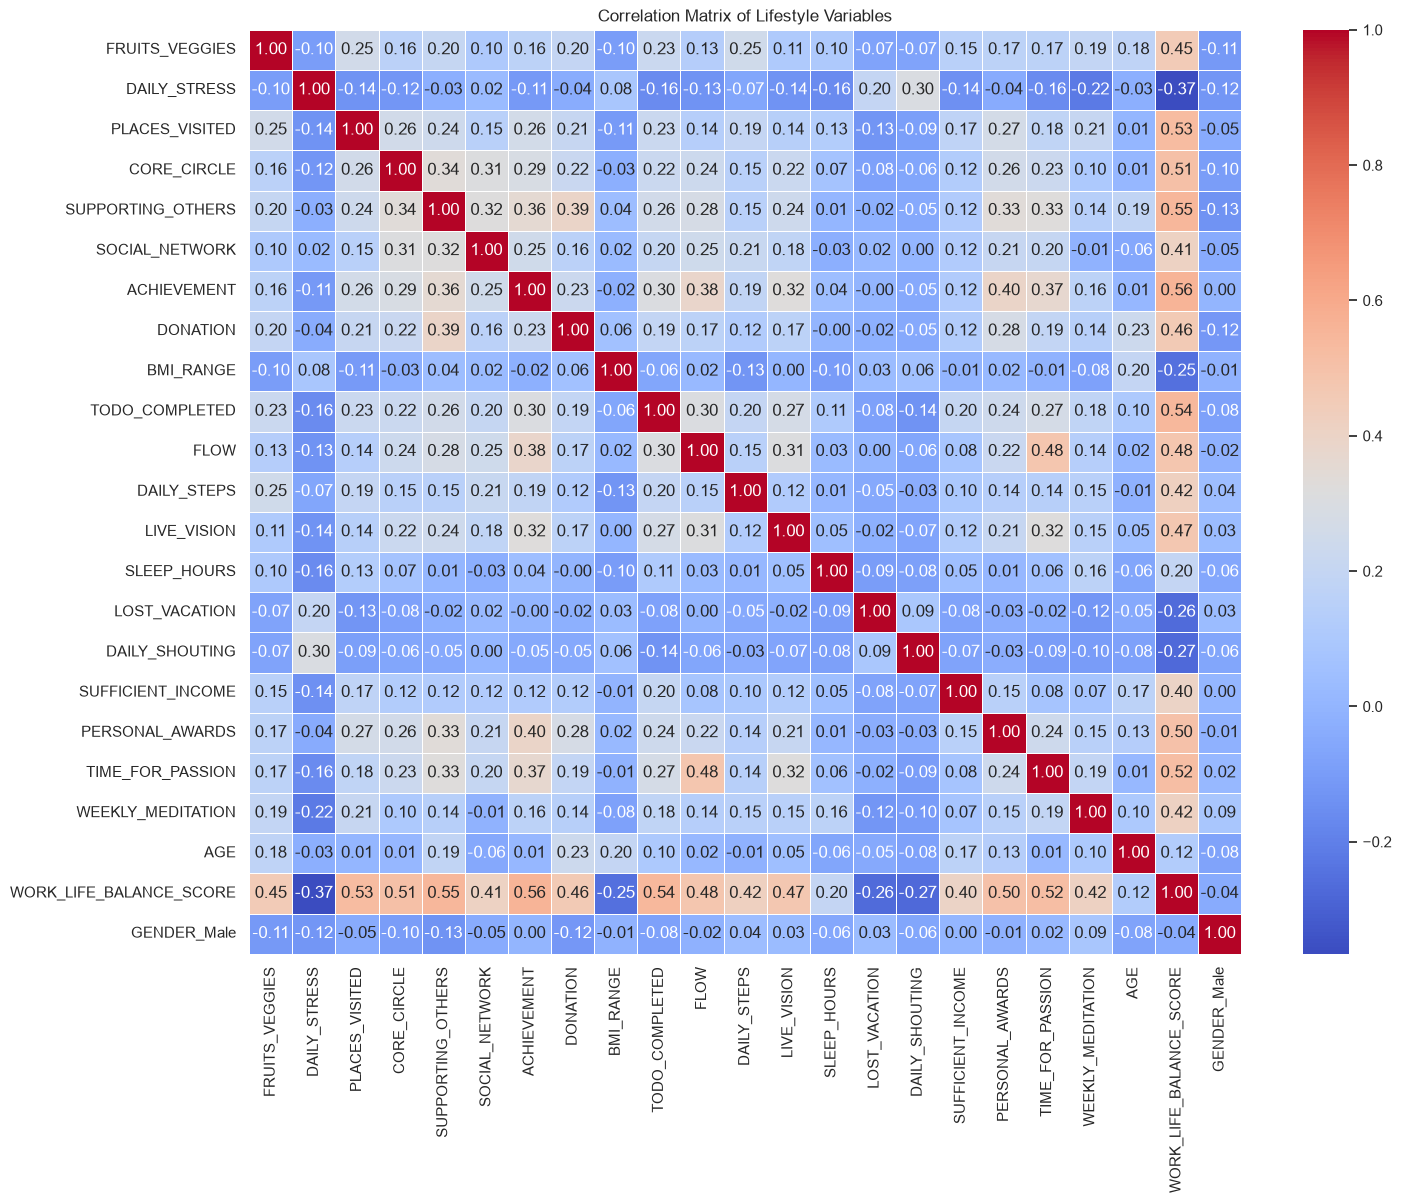

In [51]:
#Plotting the corelation matrix to show corelation between attributes

correlated = eda_df.corr()
plt.figure(figsize= (16,12))
sns.heatmap(correlated, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Lifestyle Variables')
plt.show()

# Creating Boxplots

In [ ]:
numerical_features = eda_df.select_dtypes(
    include=["int64", "float64"]
).columns

for feature in numerical_features:

    plt.figure(figsize=(8, 2))

    sns.boxplot(
        x=eda_df[feature]
    )

    plt.title(f"Boxplot of {feature}")

    plt.tight_layout()

    plt.show()

# Outlier Summary

In [52]:
outlier_summary = []

for feature in numerical_features:

    Q1 = eda_df[feature].quantile(0.25)
    Q3 = eda_df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (eda_df[feature] < lower) |
        (eda_df[feature] > upper)
    ).sum()

    percentage = round(count / len(eda_df) * 100, 2)

    outlier_summary.append({
        "Feature": feature,
        "Outlier Count": count,
        "Outlier Percentage": percentage
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df = outlier_df.sort_values(
    "Outlier Percentage",
    ascending=False
)

display(outlier_df)

,Feature,Outlier Count,Outlier Percentage
15,DAILY_SHOUTING,900,5.81
21,WORK_LIFE_BALANCE_SCORE,67,0.43
13,SLEEP_HOURS,38,0.25
2,PLACES_VISITED,0,0.00
0,FRUITS_VEGGIES,0,0.00
1,DAILY_STRESS,0,0.00
5,SOCIAL_NETWORK,0,0.00
4,SUPPORTING_OTHERS,0,0.00
3,CORE_CIRCLE,0,0.00
6,ACHIEVEMENT,0,0.00
